In [ ]:
import pandas
import numpy as np
import yfinance as yf
import matplotlib as plt

In [579]:
stocks = ["GC=F", "EUR=X", "MSFT", "^VVIX"]
gold  = yf.download(stocks[0], period="max", multi_level_index = False)
dollar= yf.download(stocks[1], period="max", multi_level_index = False)
microsoft = yf.download(stocks[2], period="max", multi_level_index = False)
vix = yf.download(stocks[3], period="max", multi_level_index = False)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [37]:
gold.index

DatetimeIndex(['2000-08-30', '2000-08-31', '2000-09-01', '2000-09-05',
               '2000-09-06', '2000-09-07', '2000-09-08', '2000-09-11',
               '2000-09-12', '2000-09-13',
               ...
               '2026-04-24', '2026-04-27', '2026-04-28', '2026-04-29',
               '2026-04-30', '2026-05-01', '2026-05-04', '2026-05-05',
               '2026-05-06', '2026-05-07'],
              dtype='datetime64[s]', name='Date', length=6445, freq=None)

In [554]:
def return_slice(stock, start, end): 
    slice  = stock.loc[start:end]
    slice = slice.reset_index()
    slice = slice.drop("Date", axis=1)
    return slice, len(slice)

def create_grid(stock, resolution, extra_points=2):
    first_point = int(stock.index[0])
    last_point = int(stock.index[-1])
    
    # Calculate the distance between points for the given resolution
    step_size = (last_point - first_point) / (resolution - 1)
    
    # Push the bounds outward by the step size * number of extra points
    new_first_point = first_point - (step_size * extra_points)
    new_last_point = last_point + (step_size * extra_points)
    
    # Increase the resolution to account for the new points on both sides
    new_resolution = resolution + (2 * extra_points)
    
    points = np.linspace(new_first_point, new_last_point, new_resolution, endpoint=True)
    grid_df = pandas.DataFrame(points)
    
    return grid_df

def gaussian(x, pos, width, height, overlap=1):
    gaussian = (height/overlap )* np.exp( - ((x-pos)**2) / (width**2))
    return gaussian

def many_gaussians(x, pos_list, width, height, overlap=1): 
    y=0
    for i in range(len(pos_list)):
        y += gaussian(x, pos_list.iloc[i], width, height[i], overlap)
    return y

def fit_gaussians(x, target_y, pos_list, width, overlap, lambda_reg=1.0): 
    # Flatten inputs to 1D numpy arrays
    x_vals = np.array(x).flatten()
    y_vals = np.array(target_y).flatten()
    
    
    # Initialize the design matrix A 
    A = np.zeros((len(x_vals), len(pos_list)))
    
    for i in range(len(pos_list)):
        pos = float(pos_list.iloc[i, 0])
        A[:, i] = gaussian(x_vals, pos, width, 1.0, overlap)
        
    # --- RIDGE REGULARIZATION ---
    # We add a small penalty to prevent extreme/oscillating height differences
    D = np.diff(np.eye(A.shape[1]), axis=0) 

    
    A_reg = np.vstack((A, np.sqrt(lambda_reg) * D))
    y_reg = np.concatenate((y_vals, np.zeros(D.shape[0])))
    
    # Solve using the regularized matrices
    optimal_heights, residuals, rank, s = np.linalg.lstsq(A_reg, y_reg, rcond=None)
    
    return optimal_heights

def analytical_derivative(x, pos_list, width, heights, S=1.0):
    y_prime = np.zeros(len(x))
    x_vals = np.array(x).flatten()
    for i in range(len(pos_list)):
        pos = float(pos_list.iloc[i, 0])
        # Base gaussian value
        g_val = gaussian(x_vals, pos, width, heights[i], S)
        # Multiply by the inner derivative
        y_prime += g_val * (-2 * (x_vals - pos) / (width**2))
    return pandas.DataFrame(y_prime)

def analytical_second_derivative(x, pos_list, width, heights, S=1.0):
    y_double_prime = np.zeros(len(x))
    x_vals = np.array(x).flatten()
    
    for i in range(len(pos_list)):
        pos = float(pos_list.iloc[i, 0])
        
        # 1. Get the base Gaussian value
        g_val = gaussian(x_vals, pos, width, heights[i], S)
        
        # 2. Calculate the inner mathematical term for the 2nd derivative
        term = (4 * (x_vals - pos)**2 / width**4) - (2 / width**2)
        
        # 3. Add to the total
        y_double_prime += g_val * term
        
    return pandas.DataFrame(y_double_prime)

In [580]:
gold_slice, len_gold_slice = return_slice(gold, "2015-05-07","2026-05-07")
dollar_slice, len_dollar_slice = return_slice(dollar, "2015-05-07","2026-05-07")
msft_slice, len_msft_slice = return_slice(microsoft, "2015-05-07","2026-05-07")
vix_slice, len_vix_slice = return_slice(vix, "2015-05-07","2026-05-07")

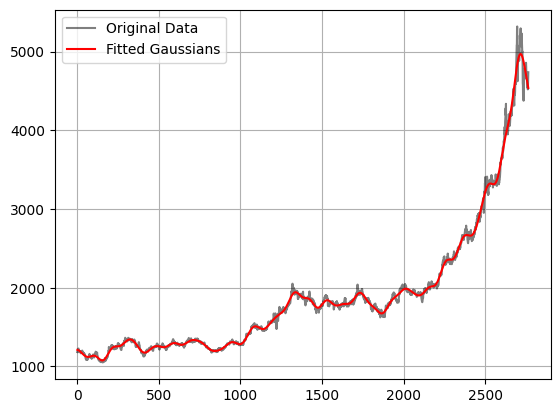

In [566]:
# 1. Define your x and target y data
# Assuming you want to fit the 'Close' prices of gold
x_data = pandas.DataFrame(gold_slice.index)
y_target = gold_slice['Close']  # Replace 'Close' with your target column

# 2. Create the grid
grid = create_grid(gold_slice, 100)
distance = grid.diff().loc[1, 0]

adjusted_width = distance * 1.5 
S_factor = (adjusted_width * np.sqrt(np.pi)) / distance 


# 3. Calculate optimal heights to fit the target
optimal_heights = fit_gaussians(x_data, y_target, grid, adjusted_width, S_factor, 0.2)

# 4. Generate the final curve using your solved heights
sum_o_gauss = many_gaussians(x_data, grid, adjusted_width, optimal_heights, S_factor)

# Plot both the original target data and the fitted curve
plt.plot(x_data, y_target, label="Original Data", color="black", alpha=0.5)
plt.plot(x_data, sum_o_gauss, label="Fitted Gaussians", color="red")
plt.grid()
plt.legend()

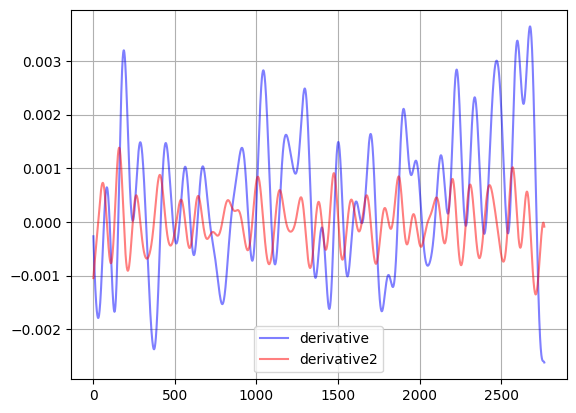

In [568]:
momentum = analytical_derivative(x_data, grid, adjusted_width, optimal_heights, S_factor) 
momentum_pct = momentum/sum_o_gauss
acc = analytical_second_derivative(x_data, grid, adjusted_width, optimal_heights, S_factor)
acc_pct = 10 * (acc * sum_o_gauss - (momentum**2)) / sum_o_gauss**2
plt.plot(x_data, momentum_pct, label="derivative", color="blue", alpha=0.5)
plt.plot(x_data, acc_pct, label="derivative2", color="red", alpha=0.5)
plt.grid()
plt.legend()

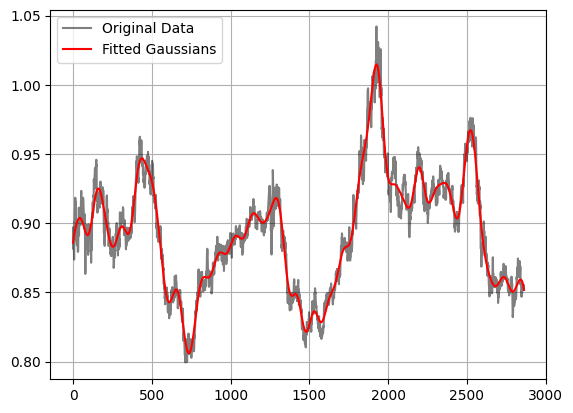

In [585]:
# 1. Define your x and target y data
# Assuming you want to fit the 'Close' prices of gold
x_data_d = pandas.DataFrame(dollar_slice.index)
y_target_d = dollar_slice['Close']  # Replace 'Close' with your target column

# 2. Create the grid
grid = create_grid(dollar_slice, 100)
distance_d = grid.diff().loc[1, 0]

adjusted_width = distance * 1.5 
S_factor = (adjusted_width * np.sqrt(np.pi)) / distance 


# 3. Calculate optimal heights to fit the target
optimal_heights_d = fit_gaussians(x_data_d, y_target_d, grid, adjusted_width, S_factor, 0.2)

# 4. Generate the final curve using your solved heights
sum_o_gauss_d = many_gaussians(x_data_d, grid, adjusted_width, optimal_heights_d, S_factor)

# Plot both the original target data and the fitted curve
plt.plot(x_data_d, y_target_d, label="Original Data", color="black", alpha=0.5)
plt.plot(x_data_d, sum_o_gauss_d, label="Fitted Gaussians", color="red")
plt.grid()
plt.legend()

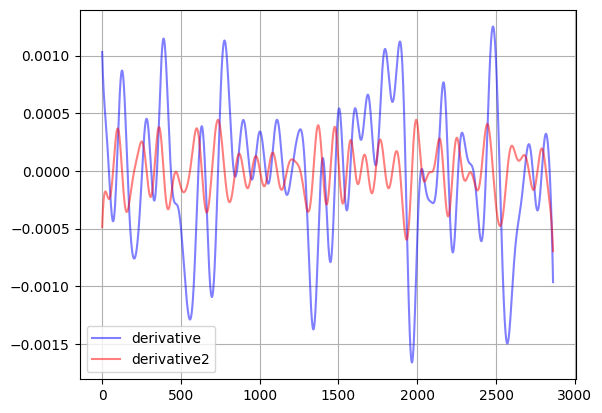

In [587]:
momentum_d = analytical_derivative(x_data_d, grid, adjusted_width, optimal_heights_d, S_factor) 
momentum_pct_d = momentum_d/sum_o_gauss_d
acc_d = analytical_second_derivative(x_data_d, grid, adjusted_width, optimal_heights_d, S_factor)
acc_pct_d = 10 * (acc_d * sum_o_gauss_d - (momentum_d**2)) / sum_o_gauss_d**2
plt.plot(x_data_d, momentum_pct_d, label="derivative", color="blue", alpha=0.5)
plt.plot(x_data_d, acc_pct_d, label="derivative2", color="red", alpha=0.5)
plt.grid()
plt.legend()

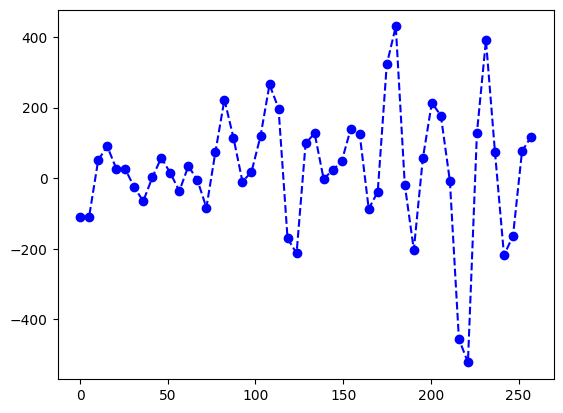